# One of the oldest applications of SVD to Machine Learning

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

## What is the problem?

We have faces (our training set) of a variety of expressions. We then get a new face. The goal is to find the closest training set face to the new face.

Computing distances in $\mathbb{R}^{m\times n}$ is expensive (slow). We will use the SVD to make this faster (cheaper).

In [5]:
# Load the data: 650 faces (50x50 pixels)
X_train = np.load('faces_train.npy')

In [6]:
X_train.shape

(2500, 540)

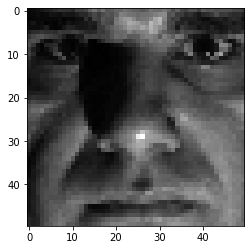

In [9]:
i = 400
plt.imshow(X_train[:,i].reshape(50,50),cmap='gray')

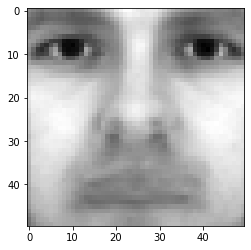

In [12]:
# average face
mean_face = np.mean(X_train, axis = 1)
plt.imshow(mean_face.reshape(50,50),cmap = 'gray')

In [14]:
#subtract the mean face from each face
X_train_centered = X_train - mean_face.reshape(2500,1)

In [15]:
# find the SVD of X_train_centered (this is expensive, it has to be done only once.)
U,S,VT = svd(X_train_centered)


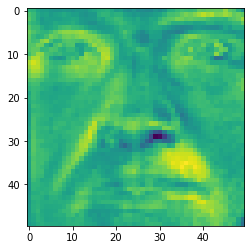

In [19]:
# The columns of U are called the eigenfaces
# They are the directions in which the faces differ from the mean
plt.imshow(U[:,20].reshape(50,50))

In [20]:
# face subspace: the space spanned by the first k columns of U

k = 50
Uk = U[:,0:k]

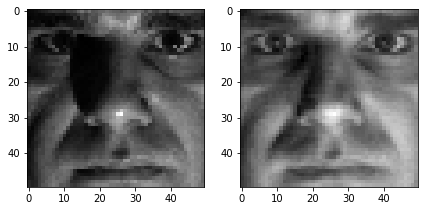

In [28]:
# each face can be approximated as a combination of the columns of Uk. Use projection matrix P = Uk*Uk^T
plt.figure(figsize=(7,7))
plt.subplot(1,2,1)
# choose a face
i = 400
face = X_train[:,i]
plt.imshow(face.reshape(50,50),cmap='gray')
plt.subplot(1,2,2)
Pface = Uk.dot(Uk.T.dot(face-mean_face))
plt.imshow((Pface+mean_face).reshape(50,50),cmap = 'gray')

In [37]:
coeffs_train = Uk.T.dot(X_train_centered)

In [35]:
# load the testing set
X_test = np.load('faces_test.npy')
X_test.shape

(2500, 100)

In [48]:
# choose a face

i = 99

face = X_test[:,i]

face_centered = face - mean_face

coeffs = Uk.T.dot(face_centered)


In [49]:
# find the closest set of coefficients from the training set
closest = np.argsort(np.linalg.norm(coeffs_train-coeffs.reshape(k,1),axis=0))[0]

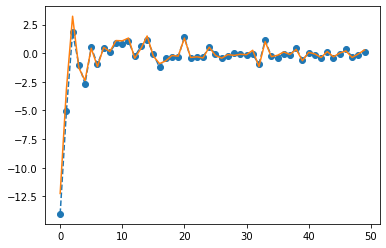

In [50]:
plt.plot(coeffs,'o--')
plt.plot(coeffs_train[:,closest])

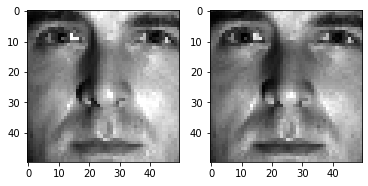

In [51]:
plt.subplot(1,2,1)
plt.imshow(X_test[:,i].reshape(50,50),cmap = 'gray')

# 'closest' traing set face
plt.subplot(1,2,2)
plt.imshow(X_train[:,closest].reshape(50,50),cmap = 'gray')